SOFTMAX on MNIST dataset

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [31]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# loading MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int32)

X /= 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# one-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.values.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.values.reshape(-1, 1))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (56000, 784)
Test data shape: (14000, 784)


In [ ]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n_samples = y_pred.shape[0]
    log_likelihood = -np.log(y_pred[range(n_samples), y_true.argmax(axis=1)])
    loss = np.sum(log_likelihood) / n_samples
    return loss

def softmax_gradient(y_pred, y_true):
    return y_pred - y_true

In [ ]:
input_size = 784  # 28x28 pixels
output_size = 10  
lr = 0.01
epochs = 300

W = np.random.randn(input_size, output_size) * 0.01
b = np.zeros((1, output_size))

In [ ]:
# training loop
for epoch in range(epochs):
    # forward pass
    z = np.dot(X_train, W) + b
    y_pred = softmax(z)
    
    loss = cross_entropy_loss(y_pred, y_train_onehot)
    
    # backward pass
    dz = softmax_gradient(y_pred, y_train_onehot)
    dW = np.dot(X_train.T, dz) / X_train.shape[0]
    db = np.sum(dz, axis=0, keepdims=True) / X_train.shape[0]
    
    # update parameters
    W -= lr * dW
    b -= lr * db
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 10/300, Loss: 2.1996
Epoch 20/300, Loss: 2.1025
Epoch 30/300, Loss: 2.0134
Epoch 40/300, Loss: 1.9311
Epoch 50/300, Loss: 1.8550
Epoch 60/300, Loss: 1.7845
Epoch 70/300, Loss: 1.7191
Epoch 80/300, Loss: 1.6585
Epoch 90/300, Loss: 1.6023
Epoch 100/300, Loss: 1.5501
Epoch 110/300, Loss: 1.5017
Epoch 120/300, Loss: 1.4567
Epoch 130/300, Loss: 1.4148
Epoch 140/300, Loss: 1.3757
Epoch 150/300, Loss: 1.3393
Epoch 160/300, Loss: 1.3053
Epoch 170/300, Loss: 1.2735
Epoch 180/300, Loss: 1.2437
Epoch 190/300, Loss: 1.2158
Epoch 200/300, Loss: 1.1895
Epoch 210/300, Loss: 1.1648
Epoch 220/300, Loss: 1.1415
Epoch 230/300, Loss: 1.1196
Epoch 240/300, Loss: 1.0989
Epoch 250/300, Loss: 1.0792
Epoch 260/300, Loss: 1.0607
Epoch 270/300, Loss: 1.0430
Epoch 280/300, Loss: 1.0263
Epoch 290/300, Loss: 1.0104
Epoch 300/300, Loss: 0.9953


Test Accuracy: 82.41%


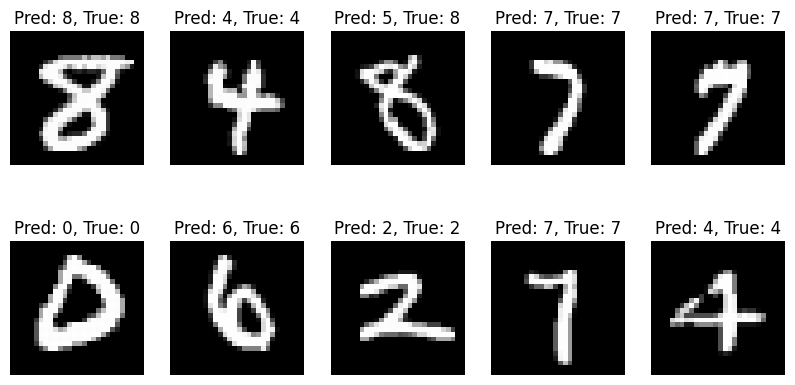

In [30]:
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
predictions = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

accuracy = np.mean(predictions == true_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test.iloc[i].values.reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {predictions[i]}, True: {true_labels[i]}")
    ax.axis('off')
plt.show()